## Problem 1: CAPM Beta Estimation for an Industry Portfolio

**Import Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

import zipfile
import requests
from io import BytesIO

print("All set!")

All set!


**Download and read Fama-French factor data**

In [4]:
ff3_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"

ff3_raw = pd.read_csv(
    ff3_url,
    compression="zip",
    skiprows=3
)

ff3_raw.head()

,Unnamed: 0,Mkt-RF,SMB,HML,RF
0,192607,2.89,-2.55,-2.39,0.22
1,192608,2.64,-1.14,3.81,0.25
2,192609,0.38,-1.36,0.05,0.23
3,192610,-3.27,-0.14,0.82,0.32
4,192611,2.54,-0.11,-0.61,0.31


**Clean the Fama-French factor data**

In [5]:
ff3 = ff3_raw.copy()

ff3 = ff3.rename(columns={ff3.columns[0]: "Date"})

ff3 = ff3[ff3["Date"].astype(str).str.isnumeric()]
ff3 = ff3[ff3["Date"].astype(str).str.len() == 6]

ff3["Date"] = pd.to_datetime(ff3["Date"].astype(str), format="%Y%m")

ff3["Mkt-RF"] = pd.to_numeric(ff3["Mkt-RF"], errors="coerce")
ff3["SMB"] = pd.to_numeric(ff3["SMB"], errors="coerce")
ff3["HML"] = pd.to_numeric(ff3["HML"], errors="coerce")
ff3["RF"] = pd.to_numeric(ff3["RF"], errors="coerce")

ff3.head()

,Date,Mkt-RF,SMB,HML,RF
0,1926-07-01,2.89,-2.55,-2.39,0.22
1,1926-08-01,2.64,-1.14,3.81,0.25
2,1926-09-01,0.38,-1.36,0.05,0.23
3,1926-10-01,-3.27,-0.14,0.82,0.32
4,1926-11-01,2.54,-0.11,-0.61,0.31


**Important:** the returns are in percent, not decimals.

**Read industry portfolio data**

In [6]:
industry_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/10_Industry_Portfolios_CSV.zip"

industry_raw = pd.read_csv(
    industry_url,
    compression="zip",
    skiprows=11
)

industry_raw.head()

,Unnamed: 0,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
0,192607,1.44,13.90,4.70,-1.14,2.90,0.83,0.12,1.85,7.04,2.14
1,192608,3.99,3.70,2.80,3.43,2.66,2.17,-0.72,4.17,-1.70,4.35
2,192609,1.15,4.98,1.17,-3.30,-0.39,2.42,0.21,0.69,2.05,0.31
3,192610,-1.24,-8.39,-3.65,-0.78,-4.58,-0.11,-2.29,-0.57,-3.27,-2.85
4,192611,5.21,-0.17,4.27,0.01,4.71,1.63,6.45,5.43,4.40,2.13


**Keep only the first monthly returns table**

In [7]:
industry = industry_raw.copy()

industry = industry.rename(columns={industry.columns[0]: "Date"})

industry["Date_as_text"] = industry["Date"].astype(str)

first_non_monthly_row = industry[
    ~industry["Date_as_text"].str.isnumeric()
].index[0]

industry = industry.loc[:first_non_monthly_row - 1]

industry.head()

,Date,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other,Date_as_text
0,192607,1.44,13.90,4.70,-1.14,2.90,0.83,0.12,1.85,7.04,2.14,192607
1,192608,3.99,3.70,2.80,3.43,2.66,2.17,-0.72,4.17,-1.70,4.35,192608
2,192609,1.15,4.98,1.17,-3.30,-0.39,2.42,0.21,0.69,2.05,0.31,192609
3,192610,-1.24,-8.39,-3.65,-0.78,-4.58,-0.11,-2.29,-0.57,-3.27,-2.85,192610
4,192611,5.21,-0.17,4.27,0.01,4.71,1.63,6.45,5.43,4.40,2.13,192611


**Clean the Industry Return Column**

In [8]:
industry = industry.drop(columns=["Date_as_text"])

industry["Date"] = pd.to_datetime(industry["Date"].astype(str), format="%Y%m")

industry["NoDur"] = pd.to_numeric(industry["NoDur"], errors="coerce")
industry["Durbl"] = pd.to_numeric(industry["Durbl"], errors="coerce")
industry["Manuf"] = pd.to_numeric(industry["Manuf"], errors="coerce")
industry["Enrgy"] = pd.to_numeric(industry["Enrgy"], errors="coerce")
industry["HiTec"] = pd.to_numeric(industry["HiTec"], errors="coerce")
industry["Telcm"] = pd.to_numeric(industry["Telcm"], errors="coerce")
industry["Shops"] = pd.to_numeric(industry["Shops"], errors="coerce")
industry["Hlth"] = pd.to_numeric(industry["Hlth"], errors="coerce")
industry["Utils"] = pd.to_numeric(industry["Utils"], errors="coerce")
industry["Other"] = pd.to_numeric(industry["Other"], errors="coerce")

industry.head()

,Date,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
0,1926-07-01,1.44,13.90,4.70,-1.14,2.90,0.83,0.12,1.85,7.04,2.14
1,1926-08-01,3.99,3.70,2.80,3.43,2.66,2.17,-0.72,4.17,-1.70,4.35
2,1926-09-01,1.15,4.98,1.17,-3.30,-0.39,2.42,0.21,0.69,2.05,0.31
3,1926-10-01,-1.24,-8.39,-3.65,-0.78,-4.58,-0.11,-2.29,-0.57,-3.27,-2.85
4,1926-11-01,5.21,-0.17,4.27,0.01,4.71,1.63,6.45,5.43,4.40,2.13


In [9]:
industry.shape

(1198, 11)

In [10]:
industry.tail()

,Date,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
1193,2025-12-01,-0.86,4.39,1.47,-0.80,-0.63,3.71,-1.32,-1.53,-4.27,1.98
1194,2026-01-01,7.00,-2.44,10.65,13.80,-0.84,3.40,5.00,0.52,2.86,-0.81
1195,2026-02-01,7.11,-4.64,7.28,8.69,-4.90,4.04,-1.78,4.63,9.90,-0.89
1196,2026-03-01,-8.05,-8.03,-9.61,12.85,-4.73,-2.61,-4.31,-7.23,-2.05,-4.93
1197,2026-04-01,2.67,3.32,7.73,-4.15,17.77,-2.26,11.77,-2.06,2.05,6.94


**Merge both datasets**

In [11]:
data = pd.merge(ff3, industry, on="Date", how="inner")

data.head()

,Date,Mkt-RF,SMB,HML,RF,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
0,1926-07-01,2.89,-2.55,-2.39,0.22,1.44,13.90,4.70,-1.14,2.90,0.83,0.12,1.85,7.04,2.14
1,1926-08-01,2.64,-1.14,3.81,0.25,3.99,3.70,2.80,3.43,2.66,2.17,-0.72,4.17,-1.70,4.35
2,1926-09-01,0.38,-1.36,0.05,0.23,1.15,4.98,1.17,-3.30,-0.39,2.42,0.21,0.69,2.05,0.31
3,1926-10-01,-3.27,-0.14,0.82,0.32,-1.24,-8.39,-3.65,-0.78,-4.58,-0.11,-2.29,-0.57,-3.27,-2.85
4,1926-11-01,2.54,-0.11,-0.61,0.31,5.21,-0.17,4.27,0.01,4.71,1.63,6.45,5.43,4.40,2.13


In [12]:
data.shape

(1198, 15)

**Create Energy Excess Return**

In [13]:
data["Enrgy_Excess"] = data["Enrgy"] - data["RF"]

data[["Date", "Enrgy", "RF", "Enrgy_Excess", "Mkt-RF"]].head()

,Date,Enrgy,RF,Enrgy_Excess,Mkt-RF
0,1926-07-01,-1.14,0.22,-1.36,2.89
1,1926-08-01,3.43,0.25,3.18,2.64
2,1926-09-01,-3.30,0.23,-3.53,0.38
3,1926-10-01,-0.78,0.32,-1.10,-3.27
4,1926-11-01,0.01,0.31,-0.30,2.54


We are not using raw Energy returns. We are using excess Energy returns, because CAPM compares returns above the risk-free rate.

**Run the Regression**

In [14]:
y = data["Enrgy_Excess"]
X = data[["Mkt-RF"]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Enrgy_Excess   R-squared:                       0.539
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     1400.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):          1.63e-203
Time:                        23:39:02   Log-Likelihood:                -3462.3
No. Observations:                1198   AIC:                             6929.
Df Residuals:                    1196   BIC:                             6939.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1553      0.127      1.223      0.2

In [15]:
alpha = model.params["const"]
beta = model.params["Mkt-RF"]
r_squared = model.rsquared
alpha_pvalue = model.pvalues["const"]
beta_pvalue = model.pvalues["Mkt-RF"]

results = pd.DataFrame({
    "Metric": ["Alpha", "Beta", "R-squared", "Alpha p-value", "Beta p-value"],
    "Value": [alpha, beta, r_squared, alpha_pvalue, beta_pvalue]
})

results

,Metric,Value
0,Alpha,1.552982e-01
1,Beta,8.878445e-01
2,R-squared,5.393167e-01
3,Alpha p-value,2.215315e-01
4,Beta p-value,1.627060e-203


**Scatter Plot**

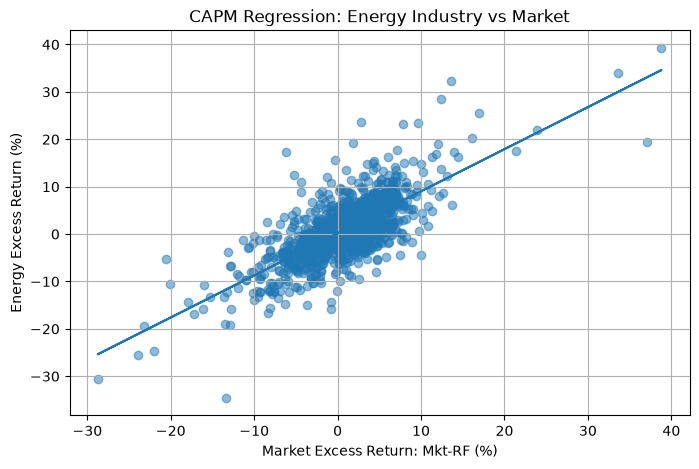

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(data["Mkt-RF"], data["Enrgy_Excess"], alpha=0.5)

x_values = data["Mkt-RF"]
y_values = model.params["const"] + model.params["Mkt-RF"] * x_values

plt.plot(x_values, y_values)

plt.xlabel("Market Excess Return: Mkt-RF (%)")
plt.ylabel("Energy Excess Return (%)")
plt.title("CAPM Regression: Energy Industry vs Market")
plt.grid(True)

plt.show()

**Residual Plot**

In [18]:
data["Predicted_Enrgy_Excess"] = model.predict(X)

data["Residuals"] = data["Enrgy_Excess"] - data["Predicted_Enrgy_Excess"]

data[["Date", "Enrgy_Excess", "Predicted_Enrgy_Excess", "Residuals"]].head()

,Date,Enrgy_Excess,Predicted_Enrgy_Excess,Residuals
0,1926-07-01,-1.36,2.721169,-4.081169
1,1926-08-01,3.18,2.499208,0.680792
2,1926-09-01,-3.53,0.492679,-4.022679
3,1926-10-01,-1.10,-2.747953,1.647953
4,1926-11-01,-0.30,2.410423,-2.710423


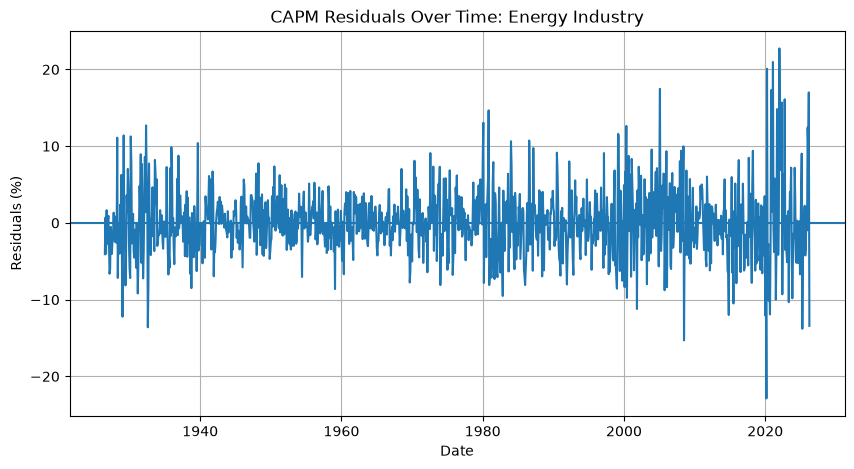

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(data["Date"], data["Residuals"])

plt.axhline(0)

plt.xlabel("Date")
plt.ylabel("Residuals (%)")
plt.title("CAPM Residuals Over Time: Energy Industry")
plt.grid(True)

plt.show()

In [20]:
data["Residuals"].describe()

count    1.198000e+03
mean    -3.469679e-16
std      4.355883e+00
min     -2.287482e+01
25%     -2.428174e+00
50%     -8.351864e-02
75%      2.212089e+00
max      2.273382e+01
Name: Residuals, dtype: float64

#### Interpretation of Residuals

The residuals from the CAPM regression are centered around zero, which suggests that the model is not systematically overpredicting or underpredicting Energy industry excess returns. The mean residual is approximately zero.

However, the residual plot shows several large positive and negative spikes, especially during periods of market stress and energy-specific shocks. This suggests that although the market excess return explains a large part of Energy industry returns, the single-factor CAPM model does not fully capture sector-specific shocks.

The standard deviation of the residuals is approximately 4.36 percentage points, meaning that the typical monthly prediction error is still economically meaningful. This supports the idea that additional variables, such as oil price changes, inflation, interest rates, or Fama-French factors, may improve the model.

## END